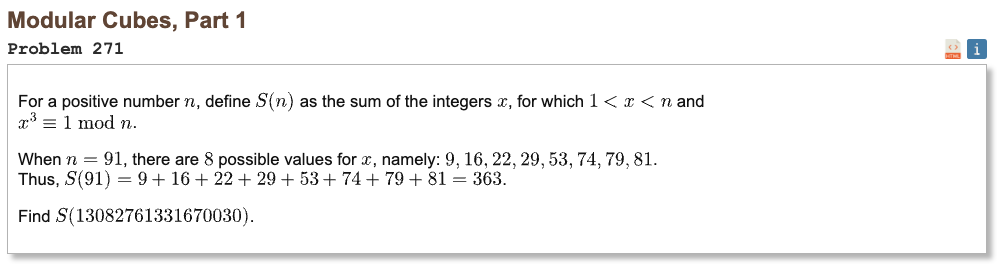

## Initial approach

* notice that 13082761331670030 is just the product of all primes from 2 to 43, so the congruence splits into separate prime mod equations by CRT
* for each prime p, solve x^3 \equiv 1 \pmod p, most primes give only the root 1, but primes congruent to 1 mod 3 give 3 roots
* in this range, the primes with 3 roots are 7, 13, 19, 31, 37, and 43, so the total number of global solutions is 3^6 = 729
* build one CRT basis value for each prime, then every full solution is just a sum of chosen local roots times those basis values
* enumerate all 729 combinations, convert each one into its unique residue modulo N, and add them up
* the value 1 is one of the solutions, but the problem wants 1 < x < n, so subtract 1 at the end
* this is small enough to do directly in Python, no heavy optimization is needed
* the final result is 4617456485273129588

In [1]:
from math import prod

def solve():
    primes = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43]
    n = prod(primes)

    roots_by_prime = []
    for p in primes:
        roots = []
        for x in range(1, p):
            if pow(x, 3, p) == 1:
                roots.append(x)
        roots_by_prime.append(roots)

    basis = []
    for p in primes:
        m = n // p
        inv = pow(m, -1, p)
        basis.append((m * inv) % n)

    result = 0

    def dfs(i, current):
        nonlocal result
        if i == len(primes):
            result += current % n
            return
        for r in roots_by_prime[i]:
            dfs(i + 1, current + r * basis[i])

    dfs(0, 0)

    result -= 1
    return result

In [2]:
%%time
result = solve()
print("Result:", result)

Result: 4617456485273129588
CPU times: user 718 μs, sys: 49 μs, total: 767 μs
Wall time: 746 μs
